This is a companion notebook for the book [Deep Learning with Python, Second Edition](https://www.manning.com/books/deep-learning-with-python-second-edition?a_aid=keras&a_bid=76564dff). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

This notebook was generated for TensorFlow 2.6.

# Deep learning for timeseries

## Different kinds of timeseries tasks

## A temperature-forecasting example

In [ ]:
!pip install tensorflow==2.12

  Using cached tensorflow-2.12.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.4 kB)
  Using cached jaxlib-0.4.30-cp311-cp311-manylinux2014_x86_64.whl.metadata (1.0 kB)
Using cached tensorflow-2.12.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (586.0 MB)
Using cached jaxlib-0.4.30-cp311-cp311-manylinux2014_x86_64.whl (79.6 MB)


In [ ]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2025-04-05 08:01:30--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 3.5.2.32, 52.217.228.208, 54.231.129.232, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|3.5.2.32|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  5.48MB/s    in 2.4s    

2025-04-05 08:01:34 (5.48 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


**Inspecting the data of the Jena weather dataset**

In [ ]:
import os
fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


**Parsing the data**

In [ ]:
import numpy as np
temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

**Plotting the temperature timeseries**

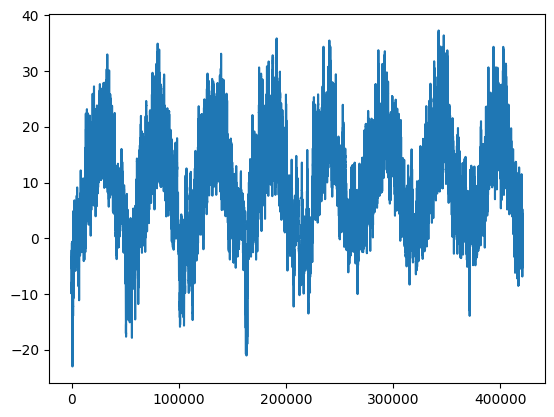

In [ ]:
from matplotlib import pyplot as plt
plt.plot(range(len(temperature)), temperature)

**Plotting the first 10 days of the temperature timeseries**

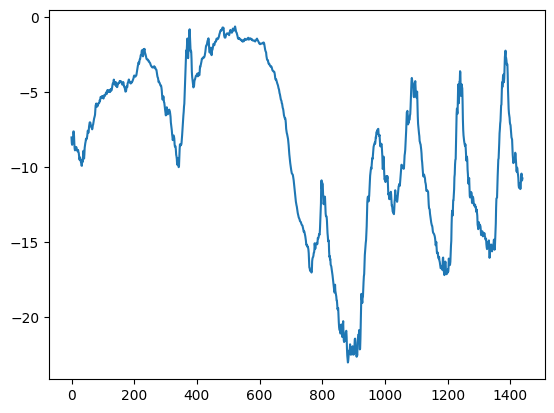

In [ ]:
plt.plot(range(1440), temperature[:1440])

**Computing the number of samples we'll use for each data split**

In [ ]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


### Preparing the data

**Normalizing the data**

In [ ]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [ ]:
import numpy as np
from tensorflow import keras
int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


**Instantiating datasets for training, validation, and testing**

In [ ]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

**Inspecting the output of one of our datasets**

In [ ]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


### A common-sense, non-machine-learning baseline

**Computing the common-sense baseline MAE**

In [ ]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


**Model 1**

### Let's try a basic machine-learning model

**Training and evaluating a densely connected model**

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Example input shape (adjust according to dataset structure)
sequence_length = 10  # Adjust according to dataset
feature_dim = raw_data.shape[-1]  # Ensure raw_data is defined

# Define the model
inputs = keras.Input(shape=(sequence_length, feature_dim))
x = layers.GlobalAveragePooling1D()(inputs)  # Replaces Flatten for sequence data
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,  # Ensure train_dataset is properly formatted
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load and evaluate the best model
model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")
print(f"Validation MAE: {min(history.history['val_mae']):.2f}")


Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 63ms/step - loss: 94.8315 - mae: 7.7797 - val_loss: 23.3535 - val_mae: 3.8249
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - loss: 22.9921 - mae: 3.8335 - val_loss: 20.6503 - val_mae: 3.5987
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 21.8322 - mae: 3.7384 - val_loss: 20.4924 - val_mae: 3.5826
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 21.6262 - mae: 3.7184 - val_loss: 20.5236 - val_mae: 3.5849
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 80s 54ms/step - loss: 21.4855 - mae: 3.7056 - val_loss: 20.5669 - val_mae: 3.5888
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 21.3819 - mae: 3.6950 - val_loss: 20.5319 - val_mae: 3.5852
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - loss: 21.2950 - mae: 3.6873 - val_loss: 20.5326 - val_mae: 3.5907
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 21.2073 - mae: 3.6795 - val_loss: 20.4192 - val_mae: 3.5860
Epoch 9/10
819/819 ━━━━━

**Plotting results**

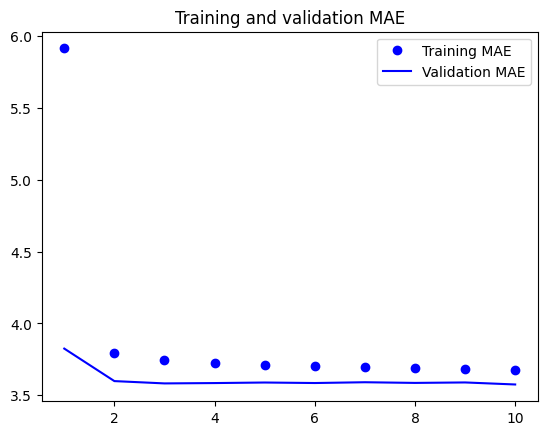

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

**Model 2**

LSTM model with three layers and 8 units

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

# Add three LSTM layers with 8 units each
x = layers.LSTM(8, return_sequences=True)(inputs)
x = layers.LSTM(8, return_sequences=True)(x)
x = layers.LSTM(8)(x)

# Output layer
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_lstm.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.1498 - mae: 0.3155 - val_loss: 0.0928 - val_mae: 0.2589
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0858 - mae: 0.2527 - val_loss: 0.0935 - val_mae: 0.2595
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0856 - mae: 0.2526 - val_loss: 0.0936 - val_mae: 0.2596
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0854 - mae: 0.2523 - val_loss: 0.0937 - val_mae: 0.2596
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0852 - mae: 0.2521 - val_loss: 0.0938 - val_mae: 0.2597
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0851 - mae: 0.2519 - val_loss: 0.0939 - val_mae: 0.2598
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0850 - mae: 0.2518 - val_loss: 0.0939 - val_mae: 0.2598
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0849 - mae: 0.2517 - val_loss: 0.0940 - val_mae: 0.2599
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.084

**Plotting results**

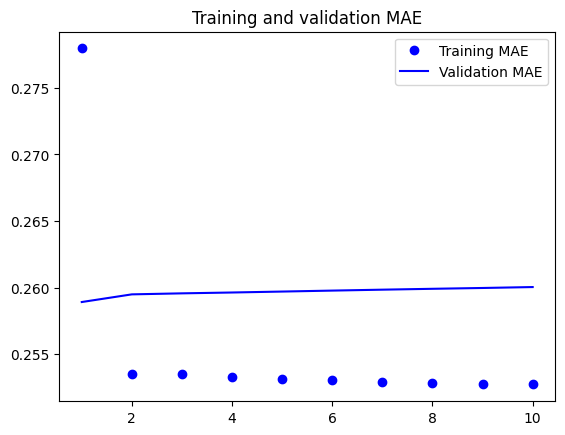

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

**Model 3**

LSTM model with three layers and 16 units

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

# Add three LSTM layers with 16 units each
x = layers.LSTM(16, return_sequences=True)(inputs)
x = layers.LSTM(16, return_sequences=True)(x)
x = layers.LSTM(16)(x)

# Output layer
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_lstm.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.1296 - mae: 0.2961 - val_loss: 0.0840 - val_mae: 0.2489
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0828 - mae: 0.2463 - val_loss: 0.0840 - val_mae: 0.2489
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0828 - mae: 0.2462 - val_loss: 0.0841 - val_mae: 0.2489
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0827 - mae: 0.2462 - val_loss: 0.0841 - val_mae: 0.2491
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0826 - mae: 0.2461 - val_loss: 0.0841 - val_mae: 0.2492
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0826 - mae: 0.2461 - val_loss: 0.0842 - val_mae: 0.2493
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0825 - mae: 0.2460 - val_loss: 0.0842 - val_mae: 0.2494
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0825 - mae: 0.2460 - val_loss: 0.0842 - val_mae: 0.2495
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.082

**Plotting results**

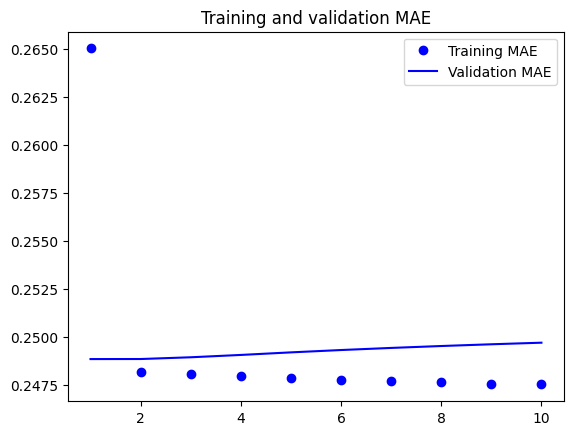

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

**Model 4**

LSTM model with three layers and 32 units

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

# Add three LSTM layers with 32 units each
x = layers.LSTM(32, return_sequences=True)(inputs)
x = layers.LSTM(32, return_sequences=True)(x)
x = layers.LSTM(32)(x)

# Output layer
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_lstm.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.1429 - mae: 0.3091 - val_loss: 0.0968 - val_mae: 0.2636
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0977 - mae: 0.2729 - val_loss: 0.0961 - val_mae: 0.2632
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0967 - mae: 0.2718 - val_loss: 0.0952 - val_mae: 0.2626
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0959 - mae: 0.2709 - val_loss: 0.0946 - val_mae: 0.2623
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0953 - mae: 0.2702 - val_loss: 0.0940 - val_mae: 0.2620
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0949 - mae: 0.2697 - val_loss: 0.0936 - val_mae: 0.2617
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0946 - mae: 0.2694 - val_loss: 0.0932 - val_mae: 0.2614
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0943 - mae: 0.2691 - val_loss: 0.0929 - val_mae: 0.2613
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.094

**Plotting results**

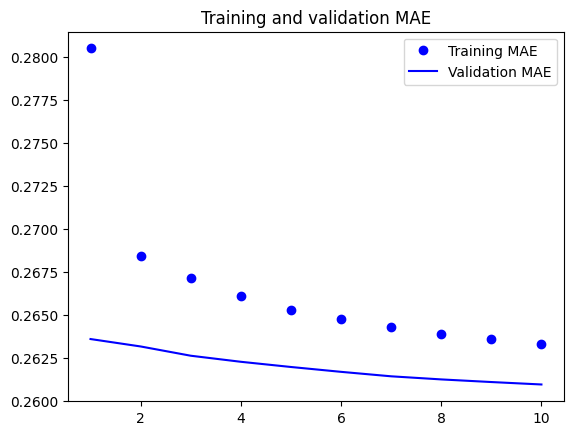

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

**Model 5**

LSTM model with four layers with 16 units

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

# Add four LSTM layers with 16 units each
x = layers.LSTM(16, return_sequences=True)(inputs)
x = layers.LSTM(16, return_sequences=True)(x)
x = layers.LSTM(16, return_sequences=True)(x)
x = layers.LSTM(16)(x)

# Output layer
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_lstm.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.1363 - mae: 0.3088 - val_loss: 0.0928 - val_mae: 0.2679
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0845 - mae: 0.2496 - val_loss: 0.0934 - val_mae: 0.2694
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0841 - mae: 0.2492 - val_loss: 0.0939 - val_mae: 0.2705
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0838 - mae: 0.2489 - val_loss: 0.0942 - val_mae: 0.2712
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0836 - mae: 0.2486 - val_loss: 0.0945 - val_mae: 0.2716
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0835 - mae: 0.2484 - val_loss: 0.0947 - val_mae: 0.2719
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0833 - mae: 0.2483 - val_loss: 0.0948 - val_mae: 0.2720
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0832 - mae: 0.2482 - val_loss: 0.0948 - val_mae: 0.2722
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.083

**Plotting results**

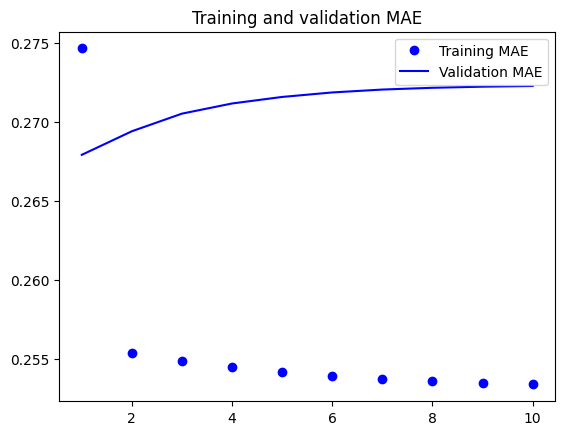

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

**Model 6**

Using gru three layers and 8 units

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

# Add three GRU layers with 8 units each
x = layers.GRU(8, return_sequences=True)(inputs)
x = layers.GRU(8, return_sequences=True)(x)
x = layers.GRU(8)(x)

# Output layer
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_gru.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_gru.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 0.1107 - mae: 0.2810 - val_loss: 0.0905 - val_mae: 0.2600
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0939 - mae: 0.2685 - val_loss: 0.0894 - val_mae: 0.2592
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0929 - mae: 0.2674 - val_loss: 0.0886 - val_mae: 0.2587
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0922 - mae: 0.2665 - val_loss: 0.0881 - val_mae: 0.2584
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0916 - mae: 0.2658 - val_loss: 0.0877 - val_mae: 0.2583
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0911 - mae: 0.2652 - val_loss: 0.0874 - val_mae: 0.2581
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0907 - mae: 0.2647 - val_loss: 0.0871 - val_mae: 0.2579
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0904 - mae: 0.2643 - val_loss: 0.0869 - val_mae: 0.2578
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.090

**Plotting results**

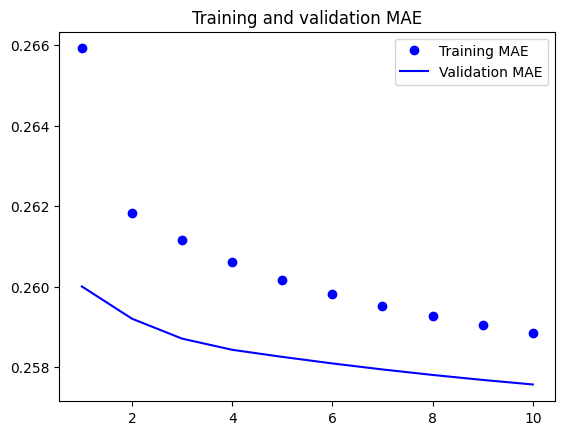

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

**Model 7**

Using gru three layers and 16 units

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

# Add three GRU layers with 16 units each
x = layers.GRU(16, return_sequences=True)(inputs)
x = layers.GRU(16, return_sequences=True)(x)
x = layers.GRU(16)(x)

# Output layer
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_gru.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_gru.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.1132 - mae: 0.2801 - val_loss: 0.0822 - val_mae: 0.2456
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0772 - mae: 0.2365 - val_loss: 0.0821 - val_mae: 0.2457
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0767 - mae: 0.2360 - val_loss: 0.0820 - val_mae: 0.2459
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0764 - mae: 0.2357 - val_loss: 0.0820 - val_mae: 0.2460
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0761 - mae: 0.2354 - val_loss: 0.0820 - val_mae: 0.2461
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0759 - mae: 0.2351 - val_loss: 0.0820 - val_mae: 0.2462
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0757 - mae: 0.2349 - val_loss: 0.0820 - val_mae: 0.2462
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0756 - mae: 0.2347 - val_loss: 0.0820 - val_mae: 0.2462
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.075

**Plotting results**

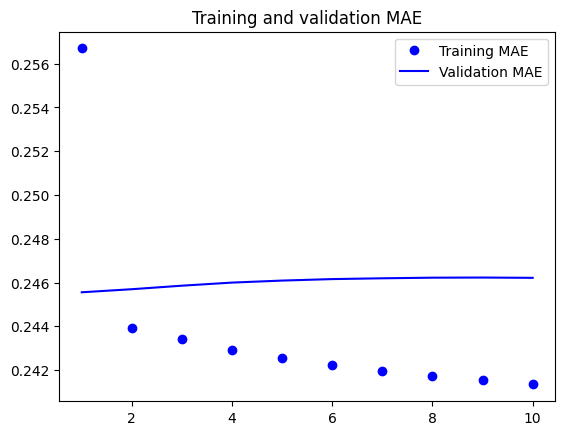

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

**Model 8**

Using gru with three layers and 32 units

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

# Add three GRU layers with 32 units each
x = layers.GRU(32, return_sequences=True)(inputs)
x = layers.GRU(32, return_sequences=True)(x)
x = layers.GRU(32)(x)

# Output layer
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_gru.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_gru.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.1449 - mae: 0.3168 - val_loss: 0.0730 - val_mae: 0.2303
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0987 - mae: 0.2734 - val_loss: 0.0732 - val_mae: 0.2309
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0963 - mae: 0.2705 - val_loss: 0.0735 - val_mae: 0.2316
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0947 - mae: 0.2683 - val_loss: 0.0738 - val_mae: 0.2322
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0937 - mae: 0.2670 - val_loss: 0.0740 - val_mae: 0.2327
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0930 - mae: 0.2660 - val_loss: 0.0743 - val_mae: 0.2332
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0924 - mae: 0.2652 - val_loss: 0.0745 - val_mae: 0.2336
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0919 - mae: 0.2645 - val_loss: 0.0747 - val_mae: 0.2339
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.091

**Plotting results**

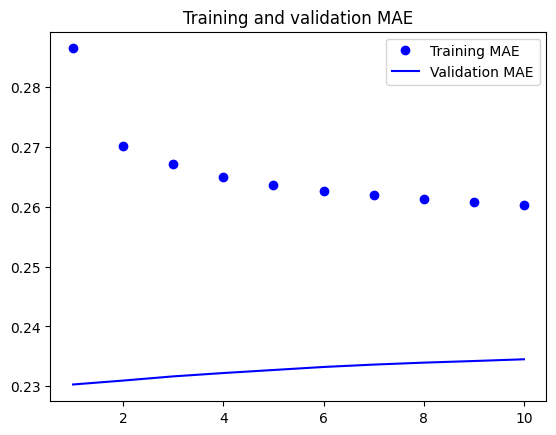

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

**Model 9**

Using gru four layers and 16 units

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(16, return_sequences=True)(inputs)
x = layers.GRU(16, return_sequences=True)(x)
x = layers.GRU(16, return_sequences=True)(x)
x = layers.GRU(16)(x)
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_gru.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_gru.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - loss: 0.3242 - mae: 0.4594 - val_loss: 0.1079 - val_mae: 0.2799
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0968 - mae: 0.2684 - val_loss: 0.1154 - val_mae: 0.2898
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0977 - mae: 0.2690 - val_loss: 0.1148 - val_mae: 0.2891
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0967 - mae: 0.2677 - val_loss: 0.1125 - val_mae: 0.2861
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0956 - mae: 0.2666 - val_loss: 0.1106 - val_mae: 0.2837
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0949 - mae: 0.2658 - val_loss: 0.1089 - val_mae: 0.2814
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0943 - mae: 0.2651 - val_loss: 0.1074 - val_mae: 0.2795
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0938 - mae: 0.2646 - val_loss: 0.1060 - val_mae: 0.2777
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0

**Plotting results**

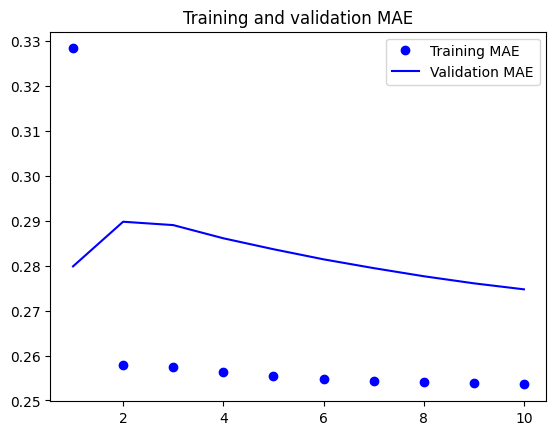

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

**Model 10**

Using 1D Convolution and LSTM

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))
val_size = int(0.2 * len(raw_data))
test_size = len(raw_data) - (train_size + val_size)

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])
        y.append(data[i + sequence_length, 0])
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(filters=32, kernel_size=3, activation='relu')(inputs)
# Set return_sequences=True for the first LSTM layer
x = layers.LSTM(32, return_sequences=True)(x)  # Change here
x = layers.LSTM(32)(x)
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_cnn_lstm.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_cnn_lstm.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.1531 - mae: 0.3158 - val_loss: 0.0783 - val_mae: 0.2417
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0843 - mae: 0.2465 - val_loss: 0.0784 - val_mae: 0.2420
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0838 - mae: 0.2461 - val_loss: 0.0784 - val_mae: 0.2422
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0831 - mae: 0.2453 - val_loss: 0.0784 - val_mae: 0.2423
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0825 - mae: 0.2446 - val_loss: 0.0784 - val_mae: 0.2424
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0821 - mae: 0.2440 - val_loss: 0.0784 - val_mae: 0.2424
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0817 - mae: 0.2436 - val_loss: 0.0784 - val_mae: 0.2425
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0815 - mae: 0.2432 - val_loss: 0.0783 - val_mae: 0.2425
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.081

**Plotting results**

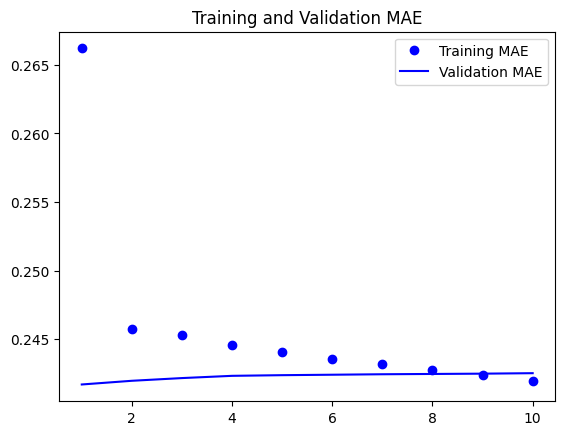

In [ ]:
# Plotting MAE like the given example
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()


**Model 11**

Using 1D Convolution and simple RNN

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(filters=32, kernel_size=3, activation='relu')(inputs)
x = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
x = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
x = layers.SimpleRNN(32, return_sequences=True)(x)
x = layers.SimpleRNN(32, return_sequences=True)(x)
x = layers.SimpleRNN(32)(x)
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_cnn_rnn.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_cnn_rnn.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")



Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.2617 - mae: 0.4161 - val_loss: 0.1740 - val_mae: 0.3512
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.1135 - mae: 0.2806 - val_loss: 0.1347 - val_mae: 0.3107
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1044 - mae: 0.2714 - val_loss: 0.1311 - val_mae: 0.3061
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1008 - mae: 0.2669 - val_loss: 0.1350 - val_mae: 0.3092
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0947 - mae: 0.2575 - val_loss: 0.1363 - val_mae: 0.3117
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0879 - mae: 0.2465 - val_loss: 0.1425 - val_mae: 0.3196
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0809 - mae: 0.2360 - val_loss: 0.1394 - val_mae: 0.3162
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0717 - mae: 0.2216 - val_loss: 0.1689 - val_mae: 0.3494
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.065

**Plotting results**

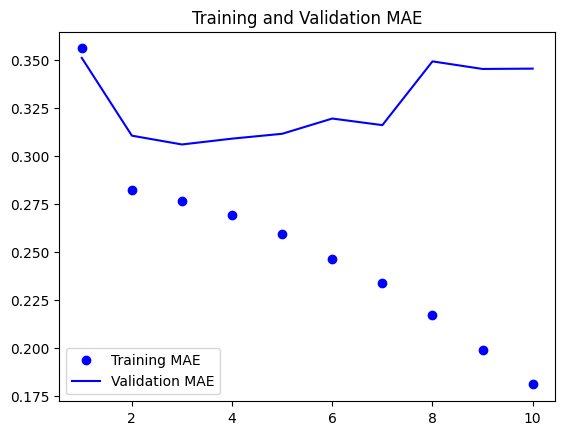

In [ ]:
# Plotting MAE like the given example
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()


**Model 12**

Using 1D Convolution and GRU

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(inputs)
x = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
x = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
x = layers.GRU(32, return_sequences=True)(x)
x = layers.GRU(32, return_sequences=True)(x)
x = layers.GRU(32)(x)
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_cnn_gru.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_cnn_gru.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")



Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.1385 - mae: 0.3084 - val_loss: 0.0822 - val_mae: 0.2443
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0835 - mae: 0.2457 - val_loss: 0.0826 - val_mae: 0.2449
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0828 - mae: 0.2448 - val_loss: 0.0826 - val_mae: 0.2450
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0816 - mae: 0.2435 - val_loss: 0.0822 - val_mae: 0.2443
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0807 - mae: 0.2426 - val_loss: 0.0817 - val_mae: 0.2435
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0799 - mae: 0.2419 - val_loss: 0.0815 - val_mae: 0.2430
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0793 - mae: 0.2414 - val_loss: 0.0815 - val_mae: 0.2430
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0788 - mae: 0.2407 - val_loss: 0.0816 - val_mae: 0.2432
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.078

**Plotting results**

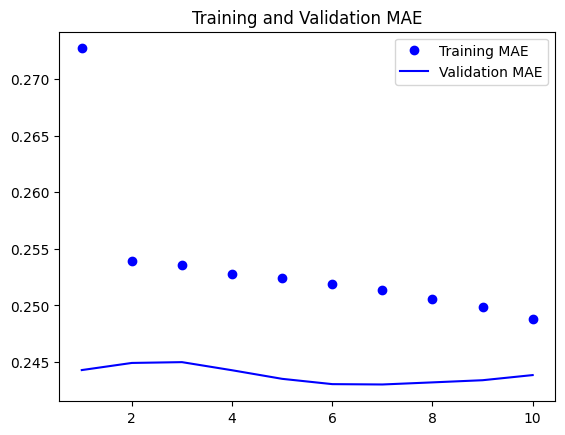

In [ ]:
# Plotting MAE like the given example
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()


**Model 13**

Using 1D Convolution, LSTM and Dropout

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(inputs)
x = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
x = layers.LSTM(32, return_sequences=True)(x)
x = layers.Dropout(0.5)(x)
x = layers.LSTM(32)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_cnn_lstm_dropout.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_cnn_lstm_dropout.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.1764 - mae: 0.3460 - val_loss: 0.0769 - val_mae: 0.2309
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1042 - mae: 0.2679 - val_loss: 0.0770 - val_mae: 0.2311
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.1077 - mae: 0.2791 - val_loss: 0.0791 - val_mae: 0.2336
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0988 - mae: 0.2664 - val_loss: 0.0760 - val_mae: 0.2296
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0965 - mae: 0.2612 - val_loss: 0.0764 - val_mae: 0.2305
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1013 - mae: 0.2660 - val_loss: 0.0760 - val_mae: 0.2298
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0976 - mae: 0.2655 - val_loss: 0.0767 - val_mae: 0.2307
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0978 - mae: 0.2710 - val_loss: 0.0758 - val_mae: 0.2295
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.098

**Plotting results**

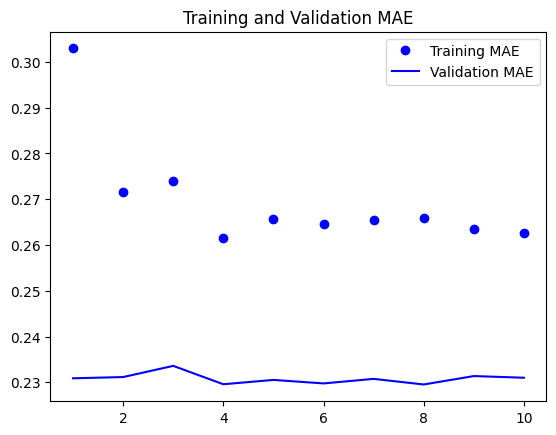

In [ ]:
# Plotting MAE like the given example
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()


**Model 14**

Using 1D Convolution, Simple RNN and Dropout

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(filters=16, kernel_size=3, activation='relu', padding='same')(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
x = layers.Dropout(0.5)(x)
x = layers.SimpleRNN(16)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_cnn_rnn_dropout.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_cnn_rnn_dropout.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.8533 - mae: 0.7495 - val_loss: 0.1720 - val_mae: 0.3359
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6738 - mae: 0.6696 - val_loss: 0.1277 - val_mae: 0.2880
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5437 - mae: 0.5921 - val_loss: 0.1422 - val_mae: 0.3049
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4952 - mae: 0.5720 - val_loss: 0.1024 - val_mae: 0.2642
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4312 - mae: 0.5189 - val_loss: 0.0928 - val_mae: 0.2530
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3485 - mae: 0.4746 - val_loss: 0.0986 - val_mae: 0.2594
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3121 - mae: 0.4540 - val_loss: 0.1307 - val_mae: 0.2931
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2660 - mae: 0.4215 - val_loss: 0.0885 - val_mae: 0.2478
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.241

**Plotting results**

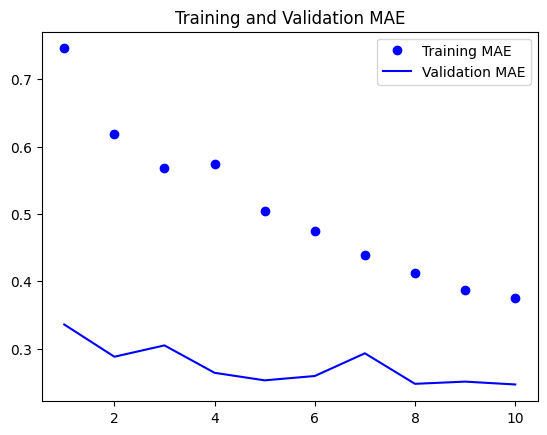

In [ ]:
# Plotting MAE like the given example
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()


**Model 15**

Using 1D Convolution, GRU and Dropout

In [2]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(inputs)
x = layers.GRU(32, return_sequences=True)(x)
x = layers.Dropout(0.5)(x)
x = layers.GRU(32)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_cnn_gru_dropout.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_cnn_gru_dropout.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.1391 - mae: 0.3004 - val_loss: 0.0954 - val_mae: 0.2642
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1096 - mae: 0.2770 - val_loss: 0.0935 - val_mae: 0.2616
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0996 - mae: 0.2651 - val_loss: 0.0907 - val_mae: 0.2585
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.1042 - mae: 0.2694 - val_loss: 0.0911 - val_mae: 0.2584
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.1071 - mae: 0.2719 - val_loss: 0.0882 - val_mae: 0.2548
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0965 - mae: 0.2633 - val_loss: 0.0882 - val_mae: 0.2544
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1002 - mae: 0.2722 - val_loss: 0.0875 - val_mae: 0.2534
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0983 - mae: 0.2670 - val_loss: 0.0868 - val_mae: 0.2525
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.092

**Plotting results**

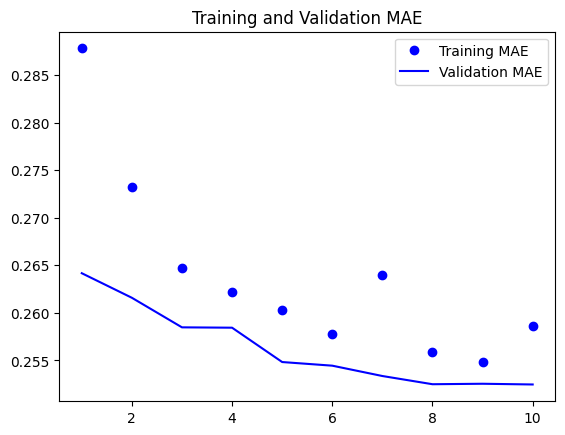

In [3]:
# Plotting MAE like the given example
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()

**Model 16**

Use Bidirectional GRU layers and Dropout

In [5]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

# Define sequence length
sequence_length = 30

# Generate dummy raw_data (1000 samples, 10 features)
raw_data = np.random.rand(1000, 10)

# Define training, validation, and test split ratios
train_size = int(0.7 * len(raw_data))  # 70% for training
val_size = int(0.2 * len(raw_data))    # 20% for validation
test_size = len(raw_data) - (train_size + val_size)  # Remaining 10% for testing

# Function to create dataset
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])  # Past `sequence_length` steps
        y.append(data[i + sequence_length, 0])   # Predict the first feature
    return np.array(X), np.array(y)

# Split data into train, validation, and test
train_data, train_labels = create_dataset(raw_data[:train_size], sequence_length)
val_data, val_labels = create_dataset(raw_data[train_size : train_size + val_size], sequence_length)
test_data, test_labels = create_dataset(raw_data[train_size + val_size:], sequence_length)

# Convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels)).batch(32)

# Define model input
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.GRU(16, return_sequences=True))(inputs)
x = layers.Dropout(0.5)(x)
x = layers.Bidirectional(layers.GRU(16, return_sequences=True))(x)
x = layers.Dropout(0.5)(x)
x = layers.Bidirectional(layers.GRU(16))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)

# Create the model
model = keras.Model(inputs, outputs)

# Define callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_bidirectional_gru.keras", save_best_only=True)
]

# Compile the model
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

# Load the best model and evaluate
model = keras.models.load_model("jena_bidirectional_gru.keras")
test_mae = model.evaluate(test_dataset)[1]
val_mae = min(history.history['val_mae'])
print(f"Test MAE: {test_mae:.2f}")
print(f"Validation MAE: {val_mae:.2f}")


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - loss: 0.2679 - mae: 0.4148 - val_loss: 0.0865 - val_mae: 0.2543
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.1334 - mae: 0.2944 - val_loss: 0.0859 - val_mae: 0.2536
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.1253 - mae: 0.2894 - val_loss: 0.0866 - val_mae: 0.2553
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.1110 - mae: 0.2783 - val_loss: 0.0853 - val_mae: 0.2529
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.1147 - mae: 0.2834 - val_loss: 0.0853 - val_mae: 0.2523
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.1158 - mae: 0.2860 - val_loss: 0.0851 - val_mae: 0.2523
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.1063 - mae: 0.2778 - val_loss: 0.0852 - val_mae: 0.2532
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.0973 - mae: 0.2565 - val_loss: 0.0849 - val_mae: 0.2523
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.1

**Plotting results**

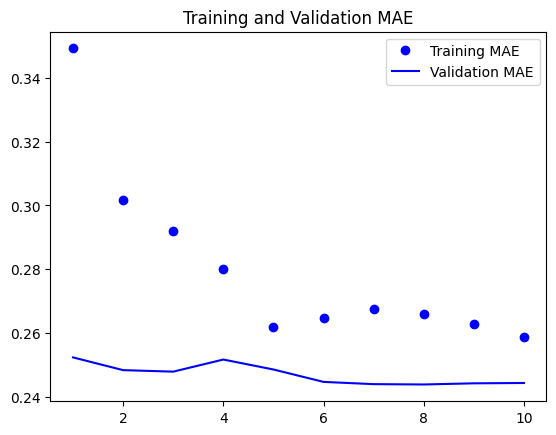

In [ ]:
# Plotting MAE like the given example
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()